In [24]:
import os
import glob
import pandas as pd
import re

# ===============================
# 폴더 경로
# ===============================
folder_path = "/home/ftk3187/github/IEMS490/model-based-diffusion_pytorch_tide/results/csv"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

summary_rows = []

for file in csv_files:
    df = pd.read_csv(file)
    name = os.path.basename(file)

    # -----------------------------
    # lambda 값 추출
    # -----------------------------
    lambda_match = re.search(r"lambda(\d+)", name)
    lambda_val = int(lambda_match.group(1)) if lambda_match else None

    # -----------------------------
    # Ndiffuse 추출 (없으면 50)
    # -----------------------------
    ndiff_match = re.search(r"Ndiffuse_(\d+)", name)
    Ndiffuse_val = int(ndiff_match.group(1)) if ndiff_match else 50

    # -----------------------------
    # Nsample 추출 (없으면 2048)
    # -----------------------------
    nsample_match = re.search(r"Nsample_(\d+)", name)
    Nsample_val = int(nsample_match.group(1)) if nsample_match else 2048

    # -----------------------------
    # 시간 추출 (첫 행)
    # -----------------------------
    total_time = df["elapsed_total_sec"].iloc[0]
    step_time = df["elapsed_per_step_sec"].iloc[0]

    summary_rows.append({
        "file": name,
        "lambda": lambda_val,
        "Ndiffuse": Ndiffuse_val,
        "Nsample": Nsample_val,
        "total_time_sec": total_time,
        "step_time_sec": step_time
    })

# ===============================
# 최종 Summary DataFrame
# ===============================
summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values(by=["lambda", "Ndiffuse", "Nsample"])

summary_df

,file,lambda,Ndiffuse,Nsample,total_time_sec,step_time_sec
13,mpc_diffusion_result_lambda0.1_Ndiffuse_10.csv,0,10,2048,22.833863,0.043083
16,mpc_diffusion_result_lambda0.1_Nsample_1024.csv,0,50,1024,90.147606,0.170090
2,mpc_diffusion_result_lambda0.1_Nsample_2048.csv,0,50,2048,92.084663,0.173745
6,mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv,0,50,2048,91.852967,0.173307
12,mpc_diffusion_result_lambda0.1_Nsample_4096.csv,0,50,4096,115.304303,0.217555
8,mpc_diffusion_result_lambda0.1_Ndiffuse_100.csv,0,100,2048,177.622060,0.335136
9,mpc_diffusion_result_lambda1_Ndiffuse_10.csv,1,10,2048,22.984002,0.043366
1,mpc_diffusion_result_lambda1_Nsample_1024.csv,1,50,1024,93.007316,0.175486
7,mpc_diffusion_result_lambda1_Ndiffuse_50.csv,1,50,2048,92.373245,0.174289
17,mpc_diffusion_result_lambda1_Nsample_2048.csv,1,50,2048,92.450708,0.174435


In [5]:
for file in csv_files:
    df = pd.read_csv(file)

    t = df["time_index"].values
    x2 = df["x2_state"].values

    C_up = 4 + 0.5 * np.sin(2 * np.pi * t / 100) - 0.004 * t
    C_low = -C_up

    data_dict[os.path.basename(file)] = {
        "t": t,
        "x2": x2,
        "C_up": C_up,
        "C_low": C_low
    }

NameError: name 'csv_files' is not defined

In [25]:
# 두 구간 정의
range_1 = (380, 440)
range_2 = (470, 530)

def compute_combined_mean_distance(t, x2, C_up, C_low, range1, range2):
    
    mask1 = (t >= range1[0]) & (t < range1[1])
    mask2 = (t >= range2[0]) & (t < range2[1])
    mask = mask1 | mask2
    
    x2_seg = x2[mask]
    up_seg = C_up[mask]
    low_seg = C_low[mask]

    dist_upper = up_seg - x2_seg
    dist_lower = x2_seg - low_seg
    dist = np.minimum(dist_upper, dist_lower)

    dist = dist[dist >= 0]

    if len(dist) == 0:
        return 0
    
    return np.mean(dist)


# 파일별 distance 저장
distance_dict = {}

for name, data in data_dict.items():
    mean_dist = compute_combined_mean_distance(
        data["t"],
        data["x2"],
        data["C_up"],
        data["C_low"],
        range_1,
        range_2
    )
    distance_dict[name] = mean_dist

In [26]:
summary_df["combined_mean_distance"] = summary_df["file"].map(distance_dict)

summary_df

,file,lambda,Ndiffuse,Nsample,total_time_sec,step_time_sec,combined_mean_distance
13,mpc_diffusion_result_lambda0.1_Ndiffuse_10.csv,0,10,2048,22.833863,0.043083,0.490888
16,mpc_diffusion_result_lambda0.1_Nsample_1024.csv,0,50,1024,90.147606,0.170090,0.276938
2,mpc_diffusion_result_lambda0.1_Nsample_2048.csv,0,50,2048,92.084663,0.173745,0.252206
6,mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv,0,50,2048,91.852967,0.173307,0.265553
12,mpc_diffusion_result_lambda0.1_Nsample_4096.csv,0,50,4096,115.304303,0.217555,0.239580
8,mpc_diffusion_result_lambda0.1_Ndiffuse_100.csv,0,100,2048,177.622060,0.335136,0.222817
9,mpc_diffusion_result_lambda1_Ndiffuse_10.csv,1,10,2048,22.984002,0.043366,0.460906
1,mpc_diffusion_result_lambda1_Nsample_1024.csv,1,50,1024,93.007316,0.175486,0.247829
7,mpc_diffusion_result_lambda1_Ndiffuse_50.csv,1,50,2048,92.373245,0.174289,0.225354
17,mpc_diffusion_result_lambda1_Nsample_2048.csv,1,50,2048,92.450708,0.174435,0.286075


In [27]:
# 파일별 violation count 저장
violation_dict = {}

for name, data in data_dict.items():
    violation = (data["x2"] > data["C_up"]) | (data["x2"] < data["C_low"])
    total_violation_count = np.sum(violation)

    violation_dict[name] = total_violation_count

summary_df["total_violation_count"] = summary_df["file"].map(violation_dict)

summary_df

,file,lambda,Ndiffuse,Nsample,total_time_sec,step_time_sec,combined_mean_distance,total_violation_count
13,mpc_diffusion_result_lambda0.1_Ndiffuse_10.csv,0,10,2048,22.833863,0.043083,0.490888,0
16,mpc_diffusion_result_lambda0.1_Nsample_1024.csv,0,50,1024,90.147606,0.170090,0.276938,2
2,mpc_diffusion_result_lambda0.1_Nsample_2048.csv,0,50,2048,92.084663,0.173745,0.252206,7
6,mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv,0,50,2048,91.852967,0.173307,0.265553,8
12,mpc_diffusion_result_lambda0.1_Nsample_4096.csv,0,50,4096,115.304303,0.217555,0.239580,9
8,mpc_diffusion_result_lambda0.1_Ndiffuse_100.csv,0,100,2048,177.622060,0.335136,0.222817,8
9,mpc_diffusion_result_lambda1_Ndiffuse_10.csv,1,10,2048,22.984002,0.043366,0.460906,0
1,mpc_diffusion_result_lambda1_Nsample_1024.csv,1,50,1024,93.007316,0.175486,0.247829,3
7,mpc_diffusion_result_lambda1_Ndiffuse_50.csv,1,50,2048,92.373245,0.174289,0.225354,4
17,mpc_diffusion_result_lambda1_Nsample_2048.csv,1,50,2048,92.450708,0.174435,0.286075,9


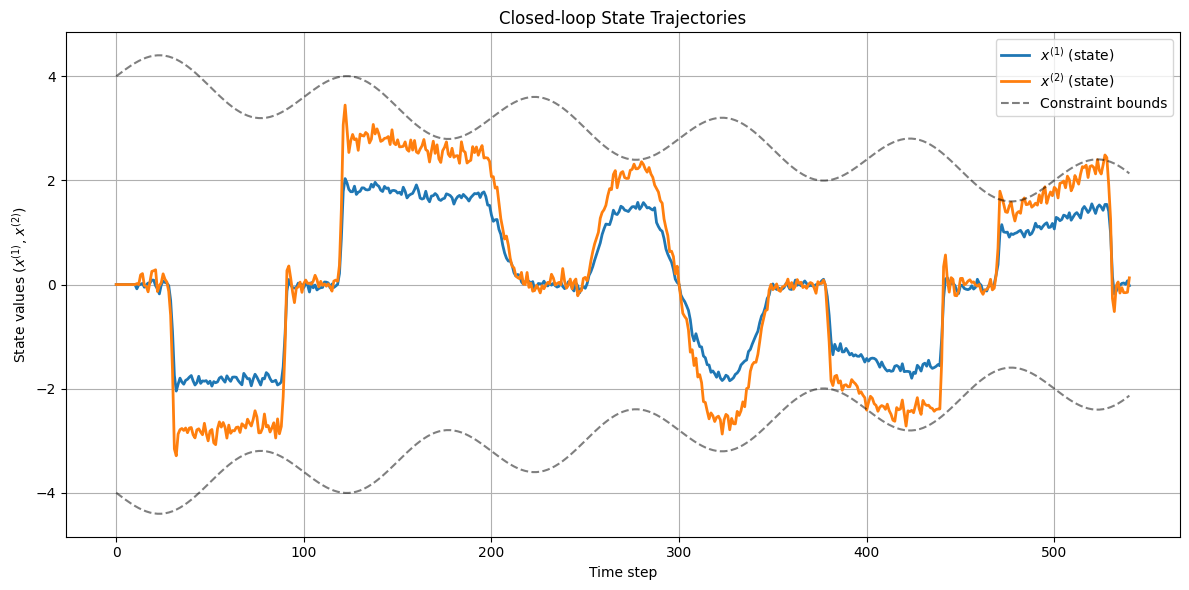

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. 파일 경로
# ===============================
file_path = "/home/ftk3187/github/IEMS490/model-based-diffusion_pytorch_tide/results/csv/mpc_diffusion_result_lambda0.1_Nsample_2048.csv"

# ===============================
# 2. 데이터 로드
# ===============================
df = pd.read_csv(file_path)

t = df["time_index"].values
x1 = df["x1_state"].values
x2 = df["x2_state"].values

# ===============================
# 3. Constraint 재계산 (x2용)
# ===============================
C_up = 4 + 0.5 * np.sin(2 * np.pi * t / 100) - 0.004 * t
C_low = -C_up

# ===============================
# 4. Plot
# ===============================
plt.figure(figsize=(12,6))

# x1 trajectory
plt.plot(t, x1, label=r"$x^{(1)}$ (state)", linewidth=2)

# x2 trajectory
plt.plot(t, x2, label=r"$x^{(2)}$ (state)", linewidth=2)

# constraint bounds
plt.plot(t, C_up, 'k--', alpha=0.5, label="Constraint bounds")
plt.plot(t, C_low, 'k--', alpha=0.5)

plt.xlabel("Time step")
plt.ylabel("State values ($x^{(1)}$, $x^{(2)}$)")
plt.title("Closed-loop State Trajectories")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# 정렬
summary_df_sorted = summary_df.sort_values(
    by=["lambda", "Ndiffuse", "Nsample"]
).reset_index(drop=True)

# ---------------------------
# Table 1: Nsample = 2048
# ---------------------------
table_1 = summary_df_sorted[
    summary_df_sorted["Nsample"] == 2048
].copy()

# ---------------------------
# Table 2: Ndiffuse = 50
# ---------------------------
table_2 = summary_df_sorted[
    summary_df_sorted["Ndiffuse"] == 50
].copy()

# Table 2에서 (2048, 50) 제거
table_2 = table_2[
    ~((table_2["Nsample"] == 2048) & (table_2["Ndiffuse"] == 50))
]

# ---------------------------
# Table 3: lambda comparison
# ---------------------------
table_3 = summary_df_sorted[
    (summary_df_sorted["Nsample"] == 2048) &
    (summary_df_sorted["Ndiffuse"] == 50)
].copy()

In [42]:
table_ndiff_1024 = summary_df[
    summary_df["Nsample"] == 2048
].copy()

# Ndiff → lambda 순 정렬
table_ndiff_1024 = table_ndiff_1024.sort_values(
    by=["Ndiffuse", "lambda"]
)

# 같은 (Ndiffuse, lambda) 조합 중 첫 번째 것만 남기기
table_ndiff_1024 = table_ndiff_1024.drop_duplicates(
    subset=["Ndiffuse", "lambda"],
    keep="first"
).reset_index(drop=True)

table_ndiff_1024

def generate_ndiff_lambda_table(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{cccccc}")
    latex.append("\\hline")
    latex.append("$N_{diff}$ & $\\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{int(row['Ndiffuse'])} & "
            f"{row['lambda']} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $N_{diff}$ with $N_{sample}=1024$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)


print(generate_ndiff_lambda_table(table_ndiff_1024))

\begin{table}[ht]
\centering
\begin{tabular}{cccccc}
\hline
$N_{diff}$ & $\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
10 & 0 & 22.83 & 0.043 & 0.491 & 0 \\
10 & 1 & 22.98 & 0.043 & 0.461 & 0 \\
10 & 2 & 22.87 & 0.043 & 0.471 & 0 \\
50 & 0 & 92.08 & 0.174 & 0.252 & 7 \\
50 & 1 & 92.37 & 0.174 & 0.225 & 4 \\
50 & 2 & 92.08 & 0.174 & 0.252 & 7 \\
100 & 0 & 177.62 & 0.335 & 0.223 & 8 \\
100 & 1 & 178.47 & 0.337 & 0.205 & 5 \\
100 & 2 & 179.05 & 0.338 & 0.218 & 8 \\
\hline
\end{tabular}
\caption{Effect of $N_{diff}$ with $N_{sample}=1024$.}
\end{table}


In [43]:
table_nsample_50 = summary_df[
    summary_df["Ndiffuse"] == 50
].copy()

# 정렬: Nsample → lambda
table_nsample_50 = table_nsample_50.sort_values(
    by=["Nsample", "lambda"]
).reset_index(drop=True)

table_nsample_50

table_nsample_50 = table_nsample_50.drop_duplicates(
    subset=["Nsample", "lambda"],
    keep="first"
).reset_index(drop=True)

def generate_nsample_table(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{cccccc}")
    latex.append("\\hline")
    latex.append("$N_{sample}$ & $\\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{int(row['Nsample'])} & "
            f"{row['lambda']} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)


print(generate_nsample_table(table_nsample_50))

\begin{table}[ht]
\centering
\begin{tabular}{cccccc}
\hline
$N_{sample}$ & $\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
1024 & 0 & 90.15 & 0.170 & 0.277 & 2 \\
1024 & 1 & 93.01 & 0.175 & 0.248 & 3 \\
1024 & 2 & 88.07 & 0.166 & 0.267 & 6 \\
2048 & 0 & 92.08 & 0.174 & 0.252 & 7 \\
2048 & 1 & 92.37 & 0.174 & 0.225 & 4 \\
2048 & 2 & 92.08 & 0.174 & 0.252 & 7 \\
4096 & 0 & 115.30 & 0.218 & 0.240 & 9 \\
4096 & 1 & 115.75 & 0.218 & 0.232 & 11 \\
4096 & 2 & 116.28 & 0.219 & 0.242 & 6 \\
\hline
\end{tabular}
\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}
\end{table}


In [34]:
def generate_table_2(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{cccccc}")
    latex.append("\\hline")
    latex.append("$\\lambda$ & $N_{sample}$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{row['lambda']} & {int(row['Nsample'])} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)

print(generate_table_2(table_2))

\begin{table}[ht]
\centering
\begin{tabular}{cccccc}
\hline
$\lambda$ & $N_{sample}$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
0 & 1024 & 90.15 & 0.170 & 0.277 & 2 \\
0 & 4096 & 115.30 & 0.218 & 0.240 & 9 \\
1 & 1024 & 93.01 & 0.175 & 0.248 & 3 \\
1 & 4096 & 115.75 & 0.218 & 0.232 & 11 \\
2 & 1024 & 88.07 & 0.166 & 0.267 & 6 \\
2 & 4096 & 116.28 & 0.219 & 0.242 & 6 \\
\hline
\end{tabular}
\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}
\end{table}


In [35]:
def generate_table_3(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{ccccc}")
    latex.append("\\hline")
    latex.append("$\\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{row['lambda']} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $\\lambda$ with $N_{diff}=50$, $N_{sample}=2048$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)

print(generate_table_3(table_3))

\begin{table}[ht]
\centering
\begin{tabular}{ccccc}
\hline
$\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
0 & 92.08 & 0.174 & 0.252 & 7 \\
0 & 91.85 & 0.173 & 0.266 & 8 \\
1 & 92.37 & 0.174 & 0.225 & 4 \\
1 & 92.45 & 0.174 & 0.286 & 9 \\
2 & 92.08 & 0.174 & 0.252 & 7 \\
2 & 92.19 & 0.174 & 0.261 & 6 \\
\hline
\end{tabular}
\caption{Effect of $\lambda$ with $N_{diff}=50$, $N_{sample}=2048$.}
\end{table}


In [19]:
import os
import glob
import pandas as pd
import numpy as np

# ===============================
# 1. 폴더 경로
# ===============================
folder_path = "/home/ftk3187/github/IEMS490/model-based-diffusion_pytorch_tide/results/csv"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
print(f"Found {len(csv_files)} CSV files")

# ===============================
# 2. 데이터 로딩 + constraint 계산
# ===============================
data_dict = {}

for file in csv_files:
    df = pd.read_csv(file)

    t = df["time_index"].values
    x2 = df["x2_state"].values

    # Constraint 재계산
    C_up = 4 + 0.5 * np.sin(2 * np.pi * t / 100) - 0.004 * t
    C_low = -C_up

    data_dict[os.path.basename(file)] = {
        "t": t,
        "x2": x2,
        "C_up": C_up,
        "C_low": C_low
    }

print("Data loaded and constraints computed.")

Found 18 CSV files
Data loaded and constraints computed.


In [20]:
# 두 구간 정의
range_1 = (380, 440)
range_2 = (470, 530)

def compute_combined_mean_distance(t, x2, C_up, C_low, range1, range2):
    
    # 두 구간 마스크 결합
    mask1 = (t >= range1[0]) & (t < range1[1])
    mask2 = (t >= range2[0]) & (t < range2[1])
    mask = mask1 | mask2
    
    x2_seg = x2[mask]
    up_seg = C_up[mask]
    low_seg = C_low[mask]

    # constraint 내부 거리 계산
    dist_upper = up_seg - x2_seg
    dist_lower = x2_seg - low_seg
    dist = np.minimum(dist_upper, dist_lower)

    # constraint 내부만 사용
    dist = dist[dist >= 0]

    if len(dist) == 0:
        return 0
    
    return np.mean(dist)


print("=== Combined Mean Distance (380–440 & 470–530) ===\n")

for name, data in data_dict.items():
    
    mean_dist = compute_combined_mean_distance(
        data["t"],
        data["x2"],
        data["C_up"],
        data["C_low"],
        range_1,
        range_2
    )

    print(f"{name}")
    print(f"  Combined Mean Distance: {mean_dist:.4f}")
    print("-" * 50)

=== Combined Mean Distance (380–440 & 470–530) ===

mpc_diffusion_result_lambda2_Nsample_2048.csv
  Combined Mean Distance: 0.2522
--------------------------------------------------
mpc_diffusion_result_lambda1_Nsample_1024.csv
  Combined Mean Distance: 0.2478
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Nsample_2048.csv
  Combined Mean Distance: 0.2522
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_50.csv
  Combined Mean Distance: 0.2607
--------------------------------------------------
mpc_diffusion_result_lambda2_Nsample_4096.csv
  Combined Mean Distance: 0.2424
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_10.csv
  Combined Mean Distance: 0.4706
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv
  Combined Mean Distance: 0.2656
--------------------------------------------------
mpc_diffusion_result_lambda1_Ndiffuse

In [21]:
print("=== Total Constraint Violations ===\n")

for name, data in data_dict.items():
    violation = (data["x2"] > data["C_up"]) | (data["x2"] < data["C_low"])
    total_violation_count = np.sum(violation)

    print(f"{name}")
    print(f"  Total Violations: {total_violation_count}")
    print("-" * 50)

=== Total Constraint Violations ===

mpc_diffusion_result_lambda2_Nsample_2048.csv
  Total Violations: 7
--------------------------------------------------
mpc_diffusion_result_lambda1_Nsample_1024.csv
  Total Violations: 3
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Nsample_2048.csv
  Total Violations: 7
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_50.csv
  Total Violations: 6
--------------------------------------------------
mpc_diffusion_result_lambda2_Nsample_4096.csv
  Total Violations: 6
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_10.csv
  Total Violations: 0
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv
  Total Violations: 8
--------------------------------------------------
mpc_diffusion_result_lambda1_Ndiffuse_50.csv
  Total Violations: 4
--------------------------------------------------
mpc_diffusi

In [22]:
print("=== Computation Time per Case ===\n")

for file in csv_files:
    df = pd.read_csv(file)
    
    name = os.path.basename(file)
    
    if "elapsed_total_sec" in df.columns:
        total_time = df["elapsed_total_sec"].iloc[0]
        step_time = df["elapsed_per_step_sec"].iloc[0]
        
        print(f"{name}")
        print(f"  Total Time (sec): {total_time:.4f}")
        print(f"  Avg Time per Step (sec): {step_time:.6f}")
        print("-" * 50)
    else:
        print(f"{name} -> No time columns found")
        print("-" * 50)

=== Computation Time per Case ===

mpc_diffusion_result_lambda2_Nsample_2048.csv
  Total Time (sec): 92.0760
  Avg Time per Step (sec): 0.173728
--------------------------------------------------
mpc_diffusion_result_lambda1_Nsample_1024.csv
  Total Time (sec): 93.0073
  Avg Time per Step (sec): 0.175486
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Nsample_2048.csv
  Total Time (sec): 92.0847
  Avg Time per Step (sec): 0.173745
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_50.csv
  Total Time (sec): 92.1891
  Avg Time per Step (sec): 0.173942
--------------------------------------------------
mpc_diffusion_result_lambda2_Nsample_4096.csv
  Total Time (sec): 116.2806
  Avg Time per Step (sec): 0.219397
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_10.csv
  Total Time (sec): 22.8670
  Avg Time per Step (sec): 0.043145
-------------------------------------------------